In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_excel(r"D:/mypy/全球健康风险因素数据集.xlsx")

In [6]:
print(df.shape)
print(df.columns.tolist())
df.head()

(92568, 6)
['country', '年份', '风险因素', '人数', '下限', '上限']


,country,年份,风险因素,人数,下限,上限
0,澳大利亚,2000,不安全的水，环境卫生和洗手,45.9042,1.5737,115.0224
1,奥地利,2000,不安全的水，环境卫生和洗手,15.4745,-0.5901,39.4465
2,比利时,2000,不安全的水，环境卫生和洗手,76.1341,0.7967,191.3115
3,加拿大,2000,不安全的水，环境卫生和洗手,113.5847,40.8570,218.9255
4,智利,2000,不安全的水，环境卫生和洗手,216.3560,80.2670,425.6548


In [7]:
df = df.dropna(how="all").dropna(axis=1, how='all').drop_duplicates()

In [8]:
numeric_cols = ["人数", "下限", "上限"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')    # 数值列转数字

df = df.dropna(subset=["country", "年份", "风险因素", "人数"])       # 删除关键列缺失值

print("处理后数据形状：", df.shape)

处理后数据形状： (92568, 6)


In [9]:
from scipy import stats
import numpy as np

z_score = np.abs(stats.zscore(df["人数"], nan_policy='omit'))
df = df[z_score < 3]

df = df.sort_values(["country", "年份"]).reset_index(drop=True)    # 按国家、年份排序，构造面板数据
print("异常值处理后形状：", df.shape)

异常值处理后形状： (91824, 6)


In [10]:
print("=== 描述统计 ===")
print(df.describe())

=== 描述统计 ===
                 年份             人数             下限             上限
count  91824.000000   91824.000000   91824.000000   91824.000000
mean    2011.498181    8864.123392    6217.912605   11515.363873
std        6.922257   24250.383801   17959.231746   31361.012612
min     2000.000000       0.017100  -31269.243700       0.041400
25%     2005.000000     121.362675      62.374975     172.301275
50%     2011.000000    1069.509050     667.288650    1477.048800
75%     2017.000000    5877.917850    3853.948575    7806.693950
max     2023.000000  279525.892600  254501.158400  451074.613700


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
risk_mean = df.groupby('风险因素')['人数'].mean().sort_values(ascending=False)
  # 计算各风险因素平均负担

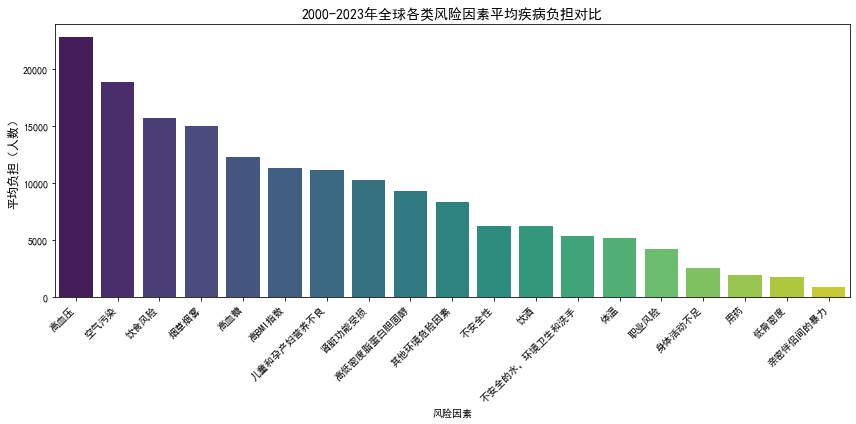

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体，支持中文
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(12, 6))
sns.barplot(x=risk_mean.index, y=risk_mean.values, palette='viridis')
plt.title('2000-2023年全球各类风险因素平均疾病负担对比', fontsize=14)
plt.ylabel('平均负担（人数）', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

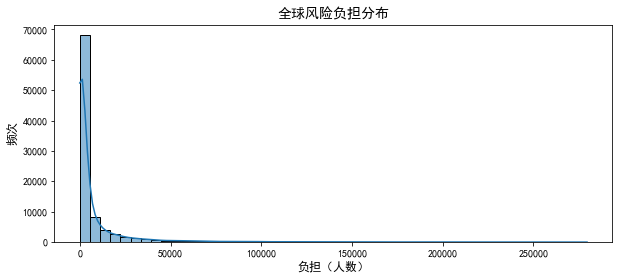

In [16]:
plt.figure(figsize=(10, 4))
sns.histplot(df['人数'], kde=True, bins=50)
plt.title('全球风险负担分布', fontsize=14)
plt.xlabel('负担（人数）', fontsize=12)
plt.ylabel('频次', fontsize=12)
plt.show()

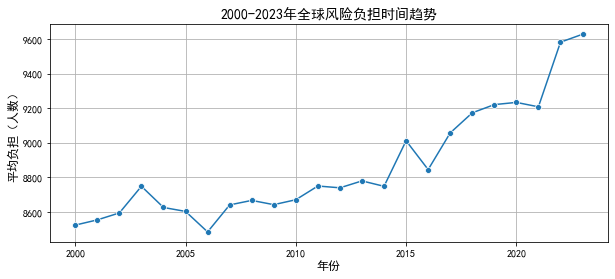

In [17]:
yearly_mean = df.groupby('年份')['人数'].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(x=yearly_mean.index, y=yearly_mean.values, marker='o')
plt.title('2000-2023年全球风险负担时间趋势', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('平均负担（人数）', fontsize=12)
plt.grid(True)
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap
import matplotlib.pyplot as pl

In [19]:
le = LabelEncoder()
df['country_enc'] = le.fit_transform(df['country'])
df['risk_enc'] = le.fit_transform(df['风险因素'])    #特征过程：编码分类变量

In [20]:
X = df[['年份', 'country_enc', 'risk_enc']]
y = df['人数']   #定义特征 X 和目标变量  
                 # X 包含：年份、国家编码、风险因素编码

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)      #训练XGBoost回归模型

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [23]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  #SHAP分析

In [24]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 结果可视化
plt.rcParams['axes.unicode_minus'] = False

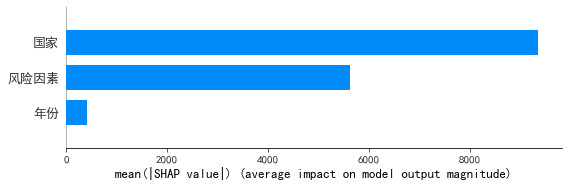

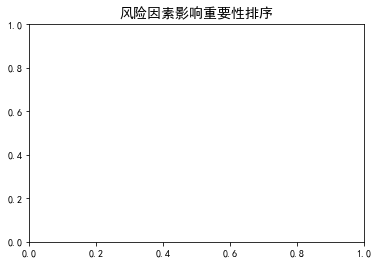

In [25]:
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=['年份', '国家', '风险因素'])
plt.title('风险因素影响重要性排序', fontsize=14)
plt.show()

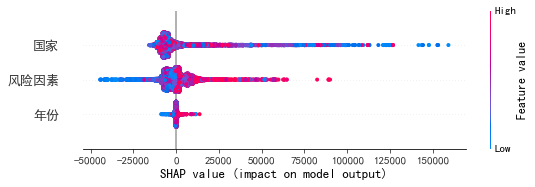

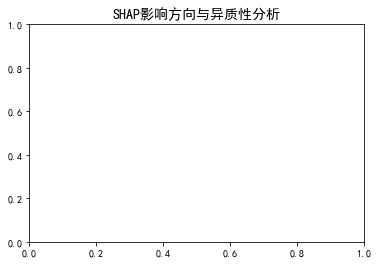

In [26]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=['年份', '国家', '风险因素'])
plt.title('SHAP影响方向与异质性分析', fontsize=14)
plt.show()    #SHAP蜂群图